In [3]:
from scipy.stats import norm, uniform

density_dist = norm(loc = 0 , scale = 1)

sunny = { "sunny":0.9 , "cloudy":0.1}
cloudy = { "sunny":0.5 , "cloudy":0.5}

nodes = { "sunny":sunny , "cloudy":cloudy}

In [ ]:
def mc(starting , nodes:dict):
    probabilities:dict = nodes[starting]
    val = 0
    rand = uniform.rvs(size = 1)
    for key in probabilities.keys():
        val += probabilities[key]
        if rand < val: 
            return key
    raise ValueError("How did you reach that")



In [18]:


N:int = int(1e6)
start = "cloudy"
dataset = []
t_list = []
sunny_index = 0


for i in range(N):
    start = mc(start, nodes)

    if start == "sunny":
        dataset.append(start)
    else:
        dataset.insert(0, start)
        sunny_index += 1

    t_list.append(sunny_index/(len(t_list)+1))


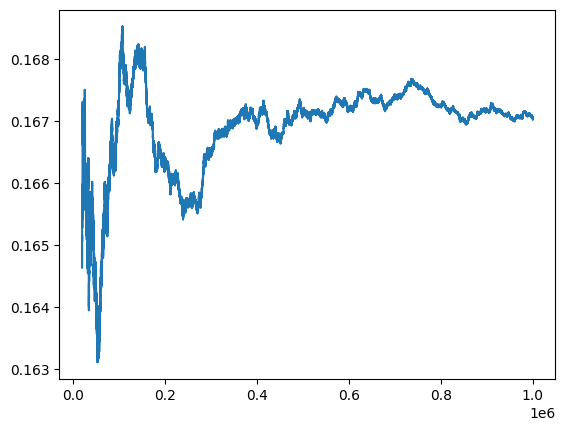

In [25]:
import matplotlib.pyplot as plt
burn_period = len(t_list)//50
plt.plot( range(burn_period, N) , t_list[burn_period::])
